In [ ]:
#Course: COSC 545
#Student: Jacob Mendez


# Download Robots Data
### First, download a bunch of robots.txt files.


## Load in urls.

In [ ]:
#from https://tranco-list.eu/list/G66YK/1000000
import csv
import os
import tldextract
tranco_rows = csv.DictReader(open("top-1m.csv"),fieldnames=["rank","domain"])#not working, need to use CSV lib

total_accepted = 0
max_accepted = 100000# you will need to have at least 10k robots.txt files
target_domains = ["us","ca","mx","br","ar","uk","ie","fr","es","pt","de","it","nl","be","ch","at","se","no","fi","dk","pl","cz","hu","gr","ro","bg","tr","ru","ua","by","cn","jp","kr","sg","in","id","th","vn","my","ph","au","nz","za","ng","ke","eg","il","sa","ae","hk","tw","eu"]
accepted_domains = []
for trow in tranco_rows:
#     print(trow)
    domain = trow["domain"]
    extract = tldextract.extract(domain)
    tld = extract.suffix
#     print(tld)
    if tld in target_domains:
        accepted_domains.append(trow["domain"])
        total_accepted += 1
    if total_accepted >= max_accepted:
        break
print(accepted_domains[0:15])
print(f"Total number of domains: {len(accepted_domains)}")

['youtu.be', 'mail.ru', 'zoom.us', 'yandex.ru', 'europa.eu', 'nic.ru', 'sberdevices.ru', 'mangosip.ru', 'stbid.ru', 'rambler.ru', 'telefonica.de', 'edgecdn.ru', 'telecid.ru', 'drom.ru', 'reg.ru']
Total number of domains: 100000


## EDA on the CSV

In [ ]:
import pandas as pd


tranco_df = pd.read_csv("top-1m.csv", header=None, names=["rank", "domain"])
tranco_df.head()

,rank,domain
0,1,google.com
1,2,amazonaws.com
2,3,facebook.com
3,4,a-msedge.net
4,5,microsoft.com


In [4]:
tot_domains = len(tranco_df)

unique_domains = tranco_df["domain"].nunique()

print(f"Total domains in file: {tot_domains}")
print(f"Unique domains: {unique_domains}")

Total domains in file: 1000000
Unique domains: 1000000


## Download robots.txt files

In [ ]:

import urllib.request

#create folder if not present
folder_name = 'robot-texts'

# Check if the folder exists, if not, create it
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

for domain in accepted_domains:
    url = "https://"+domain+"/robots.txt"
    try:
        # Open the URL
        with urllib.request.urlopen(url) as response:
            # Check if the response status code is 200 (OK)
            if response.getcode() == 200:
                # Read the raw text data
                raw_text = response.read().decode('utf-8')  # Assuming the text encoding is UTF-8
                # Output the raw text into a file
                # print(raw_text)
                outfile = open(folder_name+"/"+domain,"w")
                outfile.write(raw_text)
                outfile.close()
            else:
                print("Failed to download the file. Response code:", response.getcode())
    except Exception as e:
        print("An error occurred:",domain, e)

An error occurred: berkeley.edu HTTP Error 403: Forbidden
An error occurred: umich.edu HTTP Error 403: Forbidden
An error occurred: columbia.edu HTTP Error 403: Forbidden
An error occurred: psu.edu HTTP Error 404: Not Found
An error occurred: uci.edu HTTP Error 403: Forbidden
An error occurred: csmc.edu <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>
An error occurred: uchicago.edu HTTP Error 403: Forbidden


KeyboardInterrupt: 

In [ ]:
import os
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed
# Faster version
folder_name = 'Robot-texts'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

def download_robots(domain):
    url = "https://"+domain+"/robots.txt"
    try:
        with urllib.request.urlopen(url, timeout=10) as response:
            if response.getcode() == 200:
                raw_text = response.read().decode('utf-8')  # Assuming the text encoding is UTF-8
                # Output the raw text into a file
                # print(raw_text)
                outfile = open(folder_name+"/"+domain,"w")
                outfile.write(raw_text)
                outfile.close()
                return f"{domain} downloaded."
            else:
                return f"{domain} failed with code {response.getcode()}."
    except Exception as e:
        return f"{domain} error: {e}"
    
with ThreadPoolExecutor(max_workers=35) as executor:
    futures = [executor.submit(download_robots, domain) for domain in accepted_domains]
    for future in as_completed(futures):
        print(future.result())

telecid.ru error: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'telecid.ru'. (_ssl.c:1000)>
dzeninfra.ru error: <urlopen error [Errno -5] No address associated with hostname>
cmediahub.ru error: <urlopen error [Errno -5] No address associated with hostname>
zoom.us downloaded.
edgecdn.ru error: <urlopen error [SSL: TLSV1_ALERT_INTERNAL_ERROR] tlsv1 alert internal error (_ssl.c:1000)>
google.de downloaded.
rzone.de error: <urlopen error [Errno -5] No address associated with hostname>
youtu.be downloaded.
ok.ru downloaded.
google.ca downloaded.
europa.eu downloaded.
dbankcloud.cn error: <urlopen error [Errno -5] No address associated with hostname>
google.es downloaded.
elisa.fi downloaded.
google.fr downloaded.
google.it downloaded.
adriver.ru error: HTTP Error 404: Not Found
nic.ru downloaded.
mail.ru downloaded.
yandex.ru downloaded.
reg.ru downloaded.
google.pl downloaded.
cdek.ru error: HTTP Error 418: 
am

In [ ]:
folder_name = "Robot-texts"


records = []
for filename in os.listdir(folder_name):
    filepath = os.path.join(folder_name, filename)
    if os.path.isfile(filepath):  # skip directories
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

    
        domain = filename.replace(".txt", "")
        records.append({
            "domain": domain,
            "robots_text": text
        })
robots_df = pd.DataFrame(records)
robots_df.head()

 

,domain,robots_text
0,merca2.es,User-agent: *\nDisallow: /search/\nDisallow: /...
1,bloknot-voronezh.ru,User-Agent: *\nCrawl-delay: 20\nDisallow: /sea...
2,homestoreandmore.ie,User-agent: *\n\n# Exclude search from indexin...
3,bankingnews.gr,User-agent: SemrushBot\nDisallow: /\n\nUser-ag...
4,blesk.cz,User-agent: *\nDisallow: /vyhledavani\nDisallo...


In [ ]:
import re

def parse_robots(text):
    user_agents = re.findall(r"(?i)User-agent:\s*([^\s#]+)", text)
    disallows = re.findall(r"(?i)Disallow:\s*([^\s#]*)", text)
    allows = re.findall(r"(?i)Allow:\s*([^\s#]*)", text)
    return user_agents, disallows, allows

robots_df["user_agents"] = robots_df["robots_text"].apply(lambda x: parse_robots(x)[0])
robots_df["disallows"] = robots_df["robots_text"].apply(lambda x: parse_robots(x)[1])
robots_df["allows"] = robots_df["robots_text"].apply(lambda x: parse_robots(x)[2])

robots_df.head()

,domain,robots_text,user_agents,disallows,allows
0,merca2.es,User-agent: *\nDisallow: /search/\nDisallow: /...,[*],"[/search/, /*?s=, /?s=, /wp-admin/]","[/search/, /*?s=, /?s=, /wp-admin/]"
1,bloknot-voronezh.ru,User-Agent: *\nCrawl-delay: 20\nDisallow: /sea...,[*],"[/search/, /bitrix/, /admin/, /upload/, /img/,...","[/search/, /bitrix/, /admin/, /upload/, /img/,..."
2,homestoreandmore.ie,User-agent: *\n\n# Exclude search from indexin...,[*],"[/*Search-Show*, /*Search-GetSuggestions*, /se...","[/*Search-Show*, /*Search-GetSuggestions*, /se..."
3,bankingnews.gr,User-agent: SemrushBot\nDisallow: /\n\nUser-ag...,"[SemrushBot, SemrushBot-SA, *]","[/, /, /administrator/, /cache/, /components/,...","[/, /, /administrator/, /cache/, /components/,..."
4,blesk.cz,User-agent: *\nDisallow: /vyhledavani\nDisallo...,"[*, AhrefsBot, AhrefsSiteAudit, AwarioBot, BLE...","[/vyhledavani, /videoConfig/*, /captcha/*, /*?...","[/vyhledavani, /videoConfig/*, /captcha/*, /*?..."


## EDSA

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(len(robots_df))

10519


### Finding the most frequent bots

In [10]:
agents_df = robots_df[["domain", "user_agents"]].explode("user_agents")

In [13]:
frequent_agents = agents_df["user_agents"].value_counts()
frequent_agents.head(10)

user_agents
*                  9938
Yandex             1281
GPTBot             1249
CCBot              1095
Googlebot           937
ClaudeBot           829
Bytespider          820
ChatGPT-User        806
Google-Extended     801
AhrefsBot           798
Name: count, dtype: int64

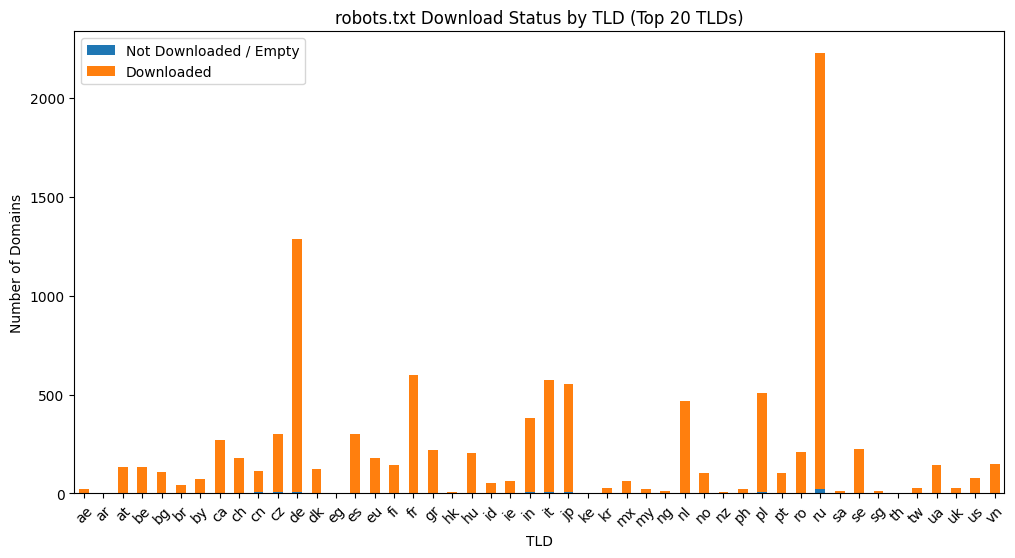

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import tldextract


extractor = tldextract.TLDExtract()
robots_df["tld"] = robots_df["domain"].apply(lambda d: extractor(d).suffix)

# was robots.txt successfully read (non-empty)?
robots_df["downloaded"] = robots_df["robots_text"].apply(lambda x: bool(x.strip()))

tld_status = robots_df.groupby("tld")["downloaded"].value_counts().unstack(fill_value=0)

tld_status.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("robots.txt Download Status by TLD (Top 20 TLDs)")
plt.ylabel("Number of Domains")
plt.xlabel("TLD")
plt.xticks(rotation=45)
plt.legend(["Not Downloaded / Empty", "Downloaded"])
plt.show()

## Most Blocked Agents

In [18]:
def get_blocked_agents(text):
    lines = text.splitlines()
    blocked = []
    current_agent = None
    disallow = False

    for line in lines:
        line = line.strip()
        if line.lower().startswith("user-agent:"):
            if current_agent and disallow:
                blocked.append(current_agent)
            current_agent = line.split(":", 1)[1].strip()
            disallow = False
        elif line.lower().startswith("disallow:"):
            path = line.split(":", 1)[1].strip()
            if path:  # non-empty path = blocked
                disallow = True
            if current_agent and disallow:
                blocked.append(current_agent)
            return blocked


In [21]:
robots_df["blocked_agents"] = robots_df["robots_text"].apply(get_blocked_agents)

blocked_df = robots_df[["domain","blocked_agents"]].explode("blocked_agents")
blocked_counts = blocked_df["blocked_agents"].value_counts()

In [22]:
print(blocked_counts)

blocked_agents
*                                     6613
Yandex                                 336
Googlebot                              118
Amazonbot                              111
GPTBot                                 103
                                      ... 
*           \t# Todos los crawlers       1
MSIECrawler                              1
RyteBotSprd_DEV-209115                   1
TosCrawler                               1
WBSearchBot                              1
Name: count, Length: 240, dtype: int64


## Domain Comparison: .us versus .eu

In [23]:
us_eu_df = robots_df[robots_df["tld"].isin(["us", "eu"])]

print(us_eu_df)

                  domain                                        robots_text  \
114             myccv.eu  # https://www.robotstxt.org/robotstxt.html\nUs...   
219          liveapps.us  <!DOCTYPE html><html><head><script>window.onlo...   
230           opsgeni.us  <!doctype html><html lang="en"><head><meta cha...   
298          jpopsuki.eu  User-agent: *\nAllow: /index.php\nAllow: /medi...   
360            dfiles.eu                       User-agent: *\nDisallow: /\n   
...                  ...                                                ...   
10364         monster.eu  <!DOCTYPE html>\n<html lang="en">\n  <head>\n ...   
10374       datadoghq.eu  User-agent: *\nAllow: /sb/\nAllow: /s/\nAllow:...   
10458  bandainamcoent.eu  #\n# robots.txt\n#\n# This file is to prevent ...   
10498      chaturbate.eu  <!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 S...   
10502          blebox.eu         User-agent: *\n\nAllow: /\n\nDisallow: /*?   

                                             user_a

## Number of successful Robots.txt downloads

In [27]:
us_eu_count = us_eu_df.groupby("tld")["robots_text"].apply(lambda x: x.str.strip().ne("").sum())
print(us_eu_count)

tld
eu    177
us     79
Name: robots_text, dtype: int64


Text(0, 0.5, 'Count')

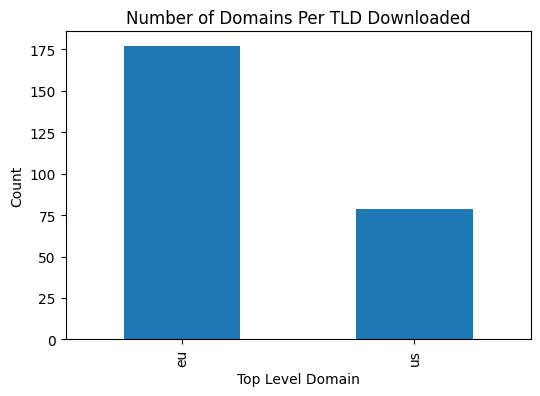

In [29]:
plt.figure(figsize=(6,4))
us_eu_count.plot(kind="bar")
plt.title("Number of Domains Per TLD Downloaded")
plt.xlabel("Top Level Domain")
plt.ylabel("Count")

## Access vs. Restriction

In [33]:
us_eu_df["fully_blocked"] = robots_df["disallows"].apply(lambda x: "/" in x)
fully_blocked = us_eu_df.groupby("tld")["fully_blocked"].count()
print(fully_blocked)

tld
eu    177
us     79
Name: fully_blocked, dtype: int64


/tmp/ipykernel_112807/2506923988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  us_eu_df["fully_blocked"] = robots_df["disallows"].apply(lambda x: "/" in x)


## AI Bot access

In [45]:
ai_bots = ["GPTBot", "CCBot", "ChatGPT-User", "anthropic-ai"]
for bot in ai_bots:
    us_eu_df[f"blocks_{bot.lower()}"] = us_eu_df["robots_text"].str.contains(bot, case=False, na=False)
ai_blocked = {bot: us_eu_df[f"blocks_{bot.lower()}"].sum() for bot in ai_bots}
ai_df = pd.DataFrame(list(ai_blocked.items()), columns=["Bot", "Count"])

print(ai_df)


            Bot  Count
0        GPTBot     16
1         CCBot     20
2  ChatGPT-User      8
3  anthropic-ai      6


/tmp/ipykernel_112807/474322461.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  us_eu_df[f"blocks_{bot.lower()}"] = us_eu_df["robots_text"].str.contains(bot, case=False, na=False)


In [46]:
ai_count_tld = us_eu_df.groupby("tld")[[f"blocks_{bot.lower()}" for bot in ai_bots]].sum().T

ai_count_tld

tld,eu,us
blocks_gptbot,9,7
blocks_ccbot,11,9
blocks_chatgpt-user,5,3
blocks_anthropic-ai,3,3


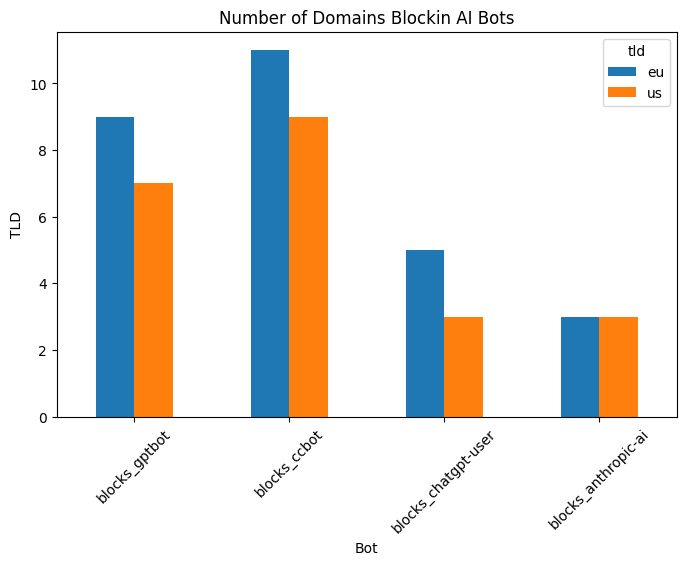

In [48]:
ai_count_tld.plot(kind="bar", figsize=(8,5))
plt.title("Number of Domains Blockin AI Bots")
plt.xlabel("Bot")
plt.ylabel("TLD")
plt.xticks(rotation=45)
plt.show()

# Reflection Section

### Q : What type of selection did you do for your urls and how many robots.txt files did you collect?
### Answer: I ultimately filtered down urls by country. There was no set process for choosing which countries, I just googled "tld's for countries" and gathered a couple random tld's. Originally I started with academia, but there were so many refused connections, I switched to something more broad to get more robot.txt files. In total, I grabbed 10,348 files. 

### Q Which user-agent(s) are blocked the most in your dataset? Do you have an idea of why?
### Answer: Most files just blocked all user-agents, but of the named ones, YandexBot was the most blocked. Yandex is a russian search engine that employs YandexBot to crawl web pages and other search engines to index content. I think a key reason why this one is the most blocked and named user agent is due to the ongoing war in the Middle East and the current Russian political climate. Fear of using this to gather intel could be the driving force for blocking YandexBot.

### Q Compare a set of domains (e.g. .edu VS .com) are there any noticable differences?
### Answer: I chose to look at "us" vs. "eu" domains to compare the block rates between us websites and european union websites. What I found is the European Union is more strict regarding web scraping and bot crawlers, which makes sense since their internet security and privacy laws are much more stringent and well defined versus US laws. We also see more ai bots being denied for eu websites versus us websites.

### Q What about GPTBot? Does it seem to have been blocked more often than others? How does it rank?
### Answer: Overall, GPTBot was ranked 4th most blocked and named user-agent. Normally I feel it would be higher, but it is ranked at about the same frequency as Googlebot and Amazonbot, at around 100 blocks. 

*                                     6613
Yandex                                 336
Googlebot                              118
Amazonbot                              111
GPTBot                                 103

### Q Do you have any final thoughts about surprising aspects of robots.txt files?
### Answer: For the assignment, I think one of the most fascinating finds of the files is the lacl of trust in Russian tools. I believed a lot of private entities would be the most blocked bots for competition reasons, but Yandex was blocked 3 times more than the second most blocked agent.